# Final pipeline - Bone age estimation

Notebook final pour assembler le pipeline complet, comparer les modeles et presenter les resultats.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid')

ROOT_DIR = Path.cwd().parents[0]
DATA_DIR = ROOT_DIR / 'data'
MODEL_DIR = ROOT_DIR / 'models'
MODEL_DIR.mkdir(exist_ok=True)
FINAL_MODEL_PATH = MODEL_DIR / 'bone_age_model.keras'
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42


def locate_metadata(data_dir: Path):
    candidates = list(data_dir.rglob('*.csv'))
    training_csv = [f for f in candidates if 'training' in f.name.lower()]
    if training_csv:
        return training_csv[0]
    if candidates:
        return candidates[0]
    raise FileNotFoundError('Aucun fichier CSV de metadonnees trouve dans data/.')
    candidates = list(data_dir.rglob('*.csv'))
    if not candidates:
        raise FileNotFoundError('Aucun fichier CSV de metadonnees trouve dans data/.')
    return candidates[0]


def build_dataset_from_dataframe(df: pd.DataFrame, image_column: str, target_column: str, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=True):
    paths = df[image_column].astype(str).tolist()
    labels = df[target_column].astype('float32').values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, image_size)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    ds = ds.map(_load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 1024), seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def build_cnn_regression_model(input_shape=(224, 224, 3), backbone='regularized_cnn'):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs, name=backbone)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mae', metrics=['mae', 'mse'])
    return model


def build_transfer_learning_model(input_shape=(224, 224, 3), weights='imagenet'):
    inputs = keras.Input(shape=input_shape)
    try:
        backbone = keras.applications.EfficientNetB0(include_top=False, weights=weights, input_shape=input_shape)
    except Exception:
        backbone = keras.applications.EfficientNetB0(include_top=False, weights=None, input_shape=input_shape)
        print('Chargement ImageNet indisponible, fallback vers weights=None.')

    backbone.trainable = False
    x = keras.applications.efficientnet.preprocess_input(inputs * 255.0)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs, name='efficientnet_bone_age')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mae', metrics=['mae', 'mse'])
    return model, backbone


def unfreeze_for_finetuning(backbone_model, n_layers=20):
    backbone_model.trainable = True
    for layer in backbone_model.layers[:-n_layers]:
        layer.trainable = False


def evaluate_regression(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'mse': mean_squared_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }


def plot_history(history, title='Training history'):
    history_df = pd.DataFrame(history.history)
    history_df[['loss', 'val_loss']].plot(title=title)
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.show()


def plot_predictions(y_true, y_pred):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_true, y=y_pred)
    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r--')
    plt.xlabel('Age reel')
    plt.ylabel('Age predit')
    plt.title('Age reel vs age predit')
    plt.show()


print('Notebook final pret: charge les donnees, entraine les modeles et exporte le meilleur modele au format .keras.')

Notebook final pret: charge les donnees, entraine les modeles et exporte le meilleur modele au format .keras.


## 1. Chargement et preparation des donnees

In [13]:
# Chargement des donnees
csv_path = locate_metadata(DATA_DIR)
print(f'CSV trouve: {csv_path}')

df = pd.read_csv(csv_path)
print(f'Nombre total d\'images: {len(df)}')
print(df.head())

CSV trouve: c:\Users\LENOVO\Desktop\4eme cycle ing\S2\ML\DLProject\data\boneage-training-dataset.csv
Nombre total d'images: 12611
     id  boneage   male
0  1377      180  False
1  1378       12  False
2  1379       94  False
3  1380      120   True
4  1381       82  False


In [14]:
# Preparation des chemins d'images
train_dir = DATA_DIR / 'boneage-training-dataset' / 'boneage-training-dataset'
test_dir = DATA_DIR / 'boneage-test-dataset' / 'boneage-test-dataset'

def get_image_path(img_id, base_dir):
    return str(base_dir / f'{img_id}.png')

df['image_path'] = df['id'].apply(lambda x: get_image_path(x, train_dir))
df = df[['image_path', 'boneage', 'male']]
df = df.rename(columns={'boneage': 'age_months'})
print(df.head())

                                          image_path  age_months   male
0  c:\Users\LENOVO\Desktop\4eme cycle ing\S2\ML\D...         180  False
1  c:\Users\LENOVO\Desktop\4eme cycle ing\S2\ML\D...          12  False
2  c:\Users\LENOVO\Desktop\4eme cycle ing\S2\ML\D...          94  False
3  c:\Users\LENOVO\Desktop\4eme cycle ing\S2\ML\D...         120   True
4  c:\Users\LENOVO\Desktop\4eme cycle ing\S2\ML\D...          82  False


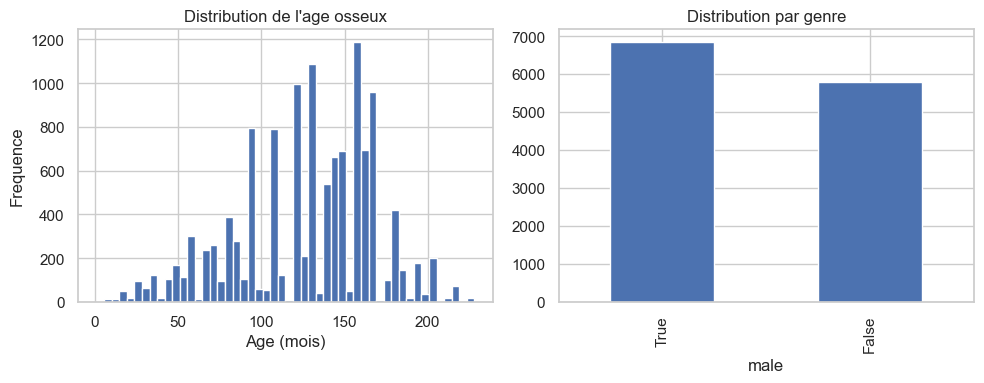

Age moyen: 127.3 mois
Ecart-type: 41.2 mois


In [15]:
# Distribution des ages
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['age_months'].hist(bins=50)
plt.xlabel('Age (mois)')
plt.ylabel('Frequence')
plt.title('Distribution de l\'age osseux')

plt.subplot(1, 2, 2)
df['male'].value_counts().plot(kind='bar')
plt.title('Distribution par genre')
plt.tight_layout()
plt.show()
print(f'Age moyen: {df["age_months"].mean():.1f} mois')
print(f'Ecart-type: {df["age_months"].std():.1f} mois')

In [16]:
# Split train/validation (80/20)
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)
print(f'Train: {len(train_df)} images, Validation: {len(val_df)} images')

Train: 10088 images, Validation: 2523 images


In [17]:
# Construction des datasets tf.data
train_ds = build_dataset_from_dataframe(
    train_df, 'image_path', 'age_months', 
    image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=True
)
val_ds = build_dataset_from_dataframe(
    val_df, 'image_path', 'age_months',
    image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

print(f'Train dataset: {train_ds}')
print(f'Validation dataset: {val_ds}')

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


## 2. Entrainement des modeles

In [18]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Entrainement CNN regularise
print('Entrainement du CNN regularise...')
cnn_model = build_cnn_regression_model(input_shape=(224, 224, 3), backbone='regularized_cnn')
cnn_model.summary()

Entrainement du CNN regularise...


Model: "regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Executer l'entrainement (ajuster EPOCHS selon ressources)
EPOCHS = 10
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 266s 412ms/step - loss: 41.1314 - mae: 41.1314 - mse: 2763.3159 - val_loss: 37.0960 - val_mae: 37.0960 - val_mse: 1939.8793 - learning_rate: 0.0010
Epoch 2/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 308s 481ms/step - loss: 36.9053 - mae: 36.9053 - mse: 2115.6658 - val_loss: 34.2346 - val_mae: 34.2346 - val_mse: 1762.8502 - learning_rate: 0.0010
Epoch 3/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 247s 385ms/step - loss: 36.3546 - mae: 36.3546 - mse: 2052.9116 - val_loss: 34.4131 - val_mae: 34.4131 - val_mse: 1755.1744 - learning_rate: 0.0010
Epoch 4/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 246s 381ms/step - loss: 37.0210 - mae: 37.0210 - mse: 2100.4099 - val_loss: 37.2416 - val_mae: 37.2416 - val_mse: 1935.5109 - learning_rate: 0.0010
Epoch 5/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 245s 382ms/step - loss: 36.0739 - mae: 36.0739 - mse: 2016.5314 - val_loss: 37.7992 - val_mae: 37.7992 - val_mse: 1976.4933 - learning_rate: 0.0010
Epoch 6/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 243s 379ms/step - lo

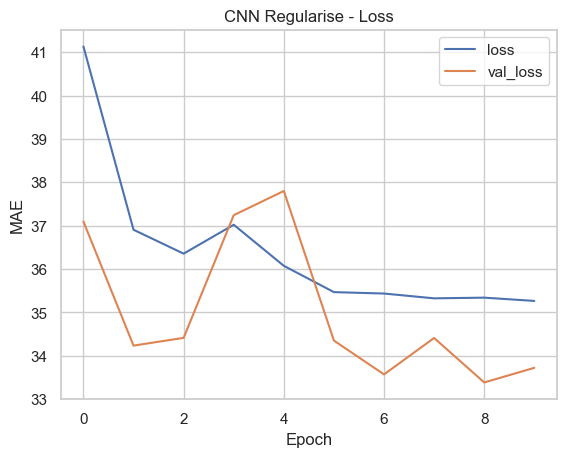

In [20]:
# Courbes d'apprentissage - CNN
plot_history(history_cnn, 'CNN Regularise - Loss')

## 3. Transfer Learning

In [21]:
# Construction du modele de transfer learning
print('Construction du modele EfficientNet transfer learning...')
tl_model, backbone = build_transfer_learning_model(input_shape=(224, 224, 3), weights='imagenet')
tl_model.summary()

Construction du modele EfficientNet transfer learning...


Model: "efficientnet_bone_age"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [22]:
# Entrainement transfer learning (tete uniquement)
print('Entrainement - phase 1: froze backbone')
history_tl_1 = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Entrainement - phase 1: froze backbone
Epoch 1/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 253s 387ms/step - loss: 31.1625 - mae: 31.1625 - mse: 1703.5931 - val_loss: 21.4036 - val_mae: 21.4036 - val_mse: 737.4275 - learning_rate: 0.0010
Epoch 2/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 249s 390ms/step - loss: 23.1606 - mae: 23.1606 - mse: 853.7916 - val_loss: 19.0680 - val_mae: 19.0680 - val_mse: 580.6353 - learning_rate: 0.0010
Epoch 3/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 250s 392ms/step - loss: 22.0465 - mae: 22.0465 - mse: 774.3389 - val_loss: 18.0879 - val_mae: 18.0879 - val_mse: 529.6136 - learning_rate: 0.0010
Epoch 4/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 247s 387ms/step - loss: 21.7670 - mae: 21.7670 - mse: 750.1905 - val_loss: 17.5905 - val_mae: 17.5905 - val_mse: 501.6926 - learning_rate: 0.0010
Epoch 5/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 246s 386ms/step - loss: 21.5269 - mae: 21.5269 - mse: 739.6002 - val_loss: 18.1103 - val_mae: 18.1103 - val_mse: 526.9652 - learning_rate: 0.0010
Epoch 6/10
631/631 ━━━━━━━━━━━

In [23]:
# Fine-tuning: degeber les dernieres couches
print('Phase 2: fine-tuning des dernieres couches')
unfreeze_for_finetuning(backbone, n_layers=20)
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='mae', 
    metrics=['mae', 'mse']
)
history_tl_2 = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Phase 2: fine-tuning des dernieres couches
Epoch 1/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 282s 431ms/step - loss: 41.7623 - mae: 41.7623 - mse: 3244.5149 - val_loss: 18.1445 - val_mae: 18.1445 - val_mse: 532.5236 - learning_rate: 1.0000e-05
Epoch 2/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 274s 429ms/step - loss: 22.3906 - mae: 22.3906 - mse: 799.8538 - val_loss: 16.6525 - val_mae: 16.6525 - val_mse: 450.3898 - learning_rate: 1.0000e-05
Epoch 3/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 279s 438ms/step - loss: 21.2902 - mae: 21.2902 - mse: 729.3777 - val_loss: 16.0587 - val_mae: 16.0587 - val_mse: 419.4355 - learning_rate: 1.0000e-05
Epoch 4/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 290s 454ms/step - loss: 20.6259 - mae: 20.6259 - mse: 682.0700 - val_loss: 15.6402 - val_mae: 15.6402 - val_mse: 394.8657 - learning_rate: 1.0000e-05
Epoch 5/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 279s 437ms/step - loss: 20.5448 - mae: 20.5448 - mse: 673.3896 - val_loss: 15.3397 - val_mae: 15.3397 - val_mse: 377.9472 - learning_rate: 1.0000e-05
Epoch 

## 4. Evaluation et comparaisons

In [24]:
# Prediction sur validation set
y_true = val_df['age_months'].values

y_pred_cnn = cnn_model.predict(val_ds, verbose=0).flatten()
results_cnn = evaluate_regression(y_true, y_pred_cnn)

y_pred_tl = tl_model.predict(val_ds, verbose=0).flatten()
results_tl = evaluate_regression(y_true, y_pred_tl)

print('Resultats CNN Regularise:', results_cnn)
print('Resultats Transfer Learning:', results_tl)

Resultats CNN Regularise: {'mae': 33.385223388671875, 'mse': 1742.7667236328125, 'r2': 0.016080379486083984}
Resultats Transfer Learning: {'mae': 14.372787475585938, 'mse': 333.74163818359375, 'r2': 0.8115783929824829}


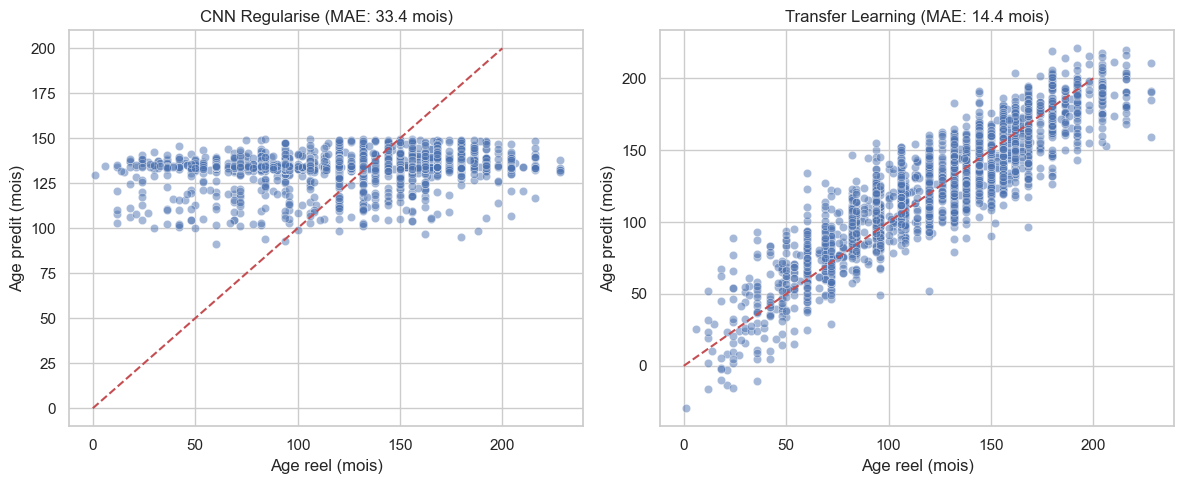

In [25]:
# Scatter plots comparatifs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_true, y=y_pred_cnn, alpha=0.5)
plt.plot([0, 200], [0, 200], 'r--')
plt.xlabel('Age reel (mois)')
plt.ylabel('Age predit (mois)')
plt.title(f'CNN Regularise (MAE: {results_cnn["mae"]:.1f} mois)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_true, y=y_pred_tl, alpha=0.5)
plt.plot([0, 200], [0, 200], 'r--')
plt.xlabel('Age reel (mois)')
plt.ylabel('Age predit (mois)')
plt.title(f'Transfer Learning (MAE: {results_tl["mae"]:.1f} mois)')

plt.tight_layout()
plt.show()

## 5. Grad-CAM - Interpretation

In [26]:
import tensorflow.keras.backend as K

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Genere une carte de chaleur Grad-CAM"""
    grad_model = keras.Model(
        model.inputs, 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_output = predictions[:, pred_index]
    
    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = K.mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ K.expand_dims(pooled_grads, -1)
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

Couche pour Grad-CAM: conv2d_5


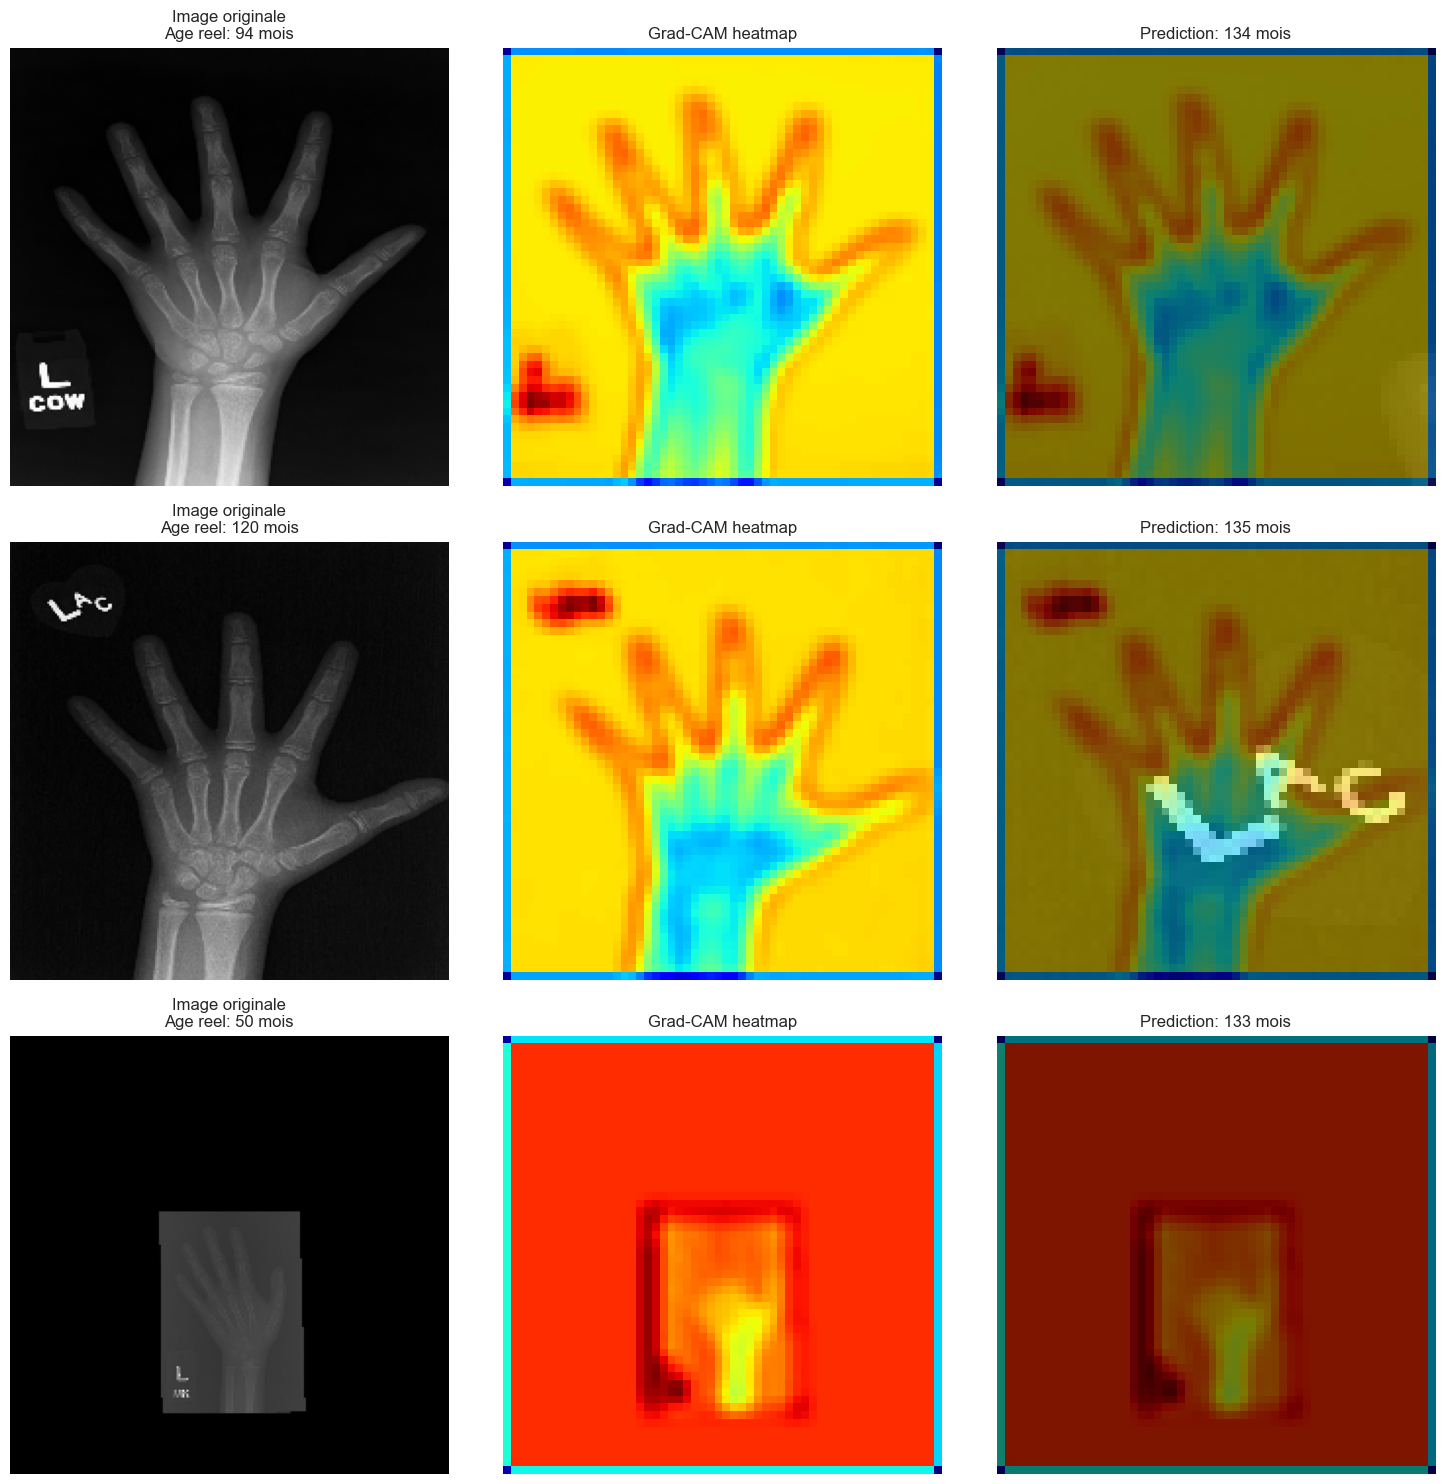

In [27]:
# Visualisation Grad-CAM sur quelques images
def visualize_gradcam(model, dataset, num_samples=3):
    plt.figure(figsize=(15, 5 * num_samples))
    
    last_conv_layer = None
    for layer in model.layers[::-1]:
        if isinstance(layer, layers.Conv2D):
            last_conv_layer = layer.name
            break
    print(f'Couche pour Grad-CAM: {last_conv_layer}')
    
    for i, (img, label) in enumerate(dataset.take(num_samples)):
        heatmap = make_gradcam_heatmap(img, model, last_conv_layer)
        
        plt.subplot(num_samples, 3, i*3+1)
        plt.imshow(img[0])
        plt.title(f'Image originale\nAge reel: {int(label[0])} mois')
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3+2)
        plt.imshow(heatmap, cmap='jet')
        plt.title('Grad-CAM heatmap')
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3+3)
        plt.imshow(img[0])
        plt.imshow(heatmap, cmap='jet', alpha=0.5)
        plt.title(f'Prediction: {int(model.predict(img, verbose=0)[0][0])} mois')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_gradcam(cnn_model, val_ds, num_samples=3)

## 6. Export du meilleur modele

In [28]:
# Sauvegarder le meilleur modele
best_model = tl_model if results_tl['mae'] < results_cnn['mae'] else cnn_model
model_name = 'EfficientNet' if results_tl['mae'] < results_cnn['mae'] else 'CNN_Regularized'

best_model.save(FINAL_MODEL_PATH)
print(f'Modele sauvegarde: {FINAL_MODEL_PATH}')
print(f'Modele selectionne: {model_name}')

Modele sauvegarde: c:\Users\LENOVO\Desktop\4eme cycle ing\S2\ML\DLProject\models\bone_age_model.keras
Modele selectionne: EfficientNet
